# Random Forest Algorithm in Machine Learning

Random Forest is an ML algorighms that uses many decision trees to make better predictions. Each tree looks at random parts of the data 
and their results are combined. For classification tasks combining is done by voting, for regression tasks by averaging. This make the algorithm ensemble learning.

Key Features of Random Forest
 - Handles Missing Data: Works only after preprocessing , as most implementations like Scikit-learn do not support missing values directly.
 - Shows Feature Importance: It tells you which features (columns) are most useful for making predictions which helps you understand your data better.
 - Works Well with Big and Complex Data: It can handle large datasets with many features without slowing down or losing accuracy.
 - Used for Different Tasks: You can use it for both classification like predicting types or labels and regression like predicting numbers or amounts.

Assumptions
 - each tree makes its own desicion
 - random parts of the data are used
 - enough data is needed
 - different predictions improve accuracy

Implementing Random Forest Classification in Python
Before implementing random forest classifier in Python let's first understand it's parameters.

 - n_estimators: Number of trees in the forest.
 - max_depth: Maximum depth of each tree.
 - max_features: Number of features considered for splitting at each node.
 - criterion: Function used to measure split quality ('gini' or 'entropy').
 - min_samples_split: Minimum samples required to split a node.
 - min_samples_leaf: Minimum samples required to be at a leaf node.
 - bootstrap: Whether to use bootstrap sampling when building trees (True or False).

### Classification Task

In [1]:
## 1. Import Libraries
# ------------------------------------------
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output presentation
warnings.filterwarnings('ignore')


In [2]:
## 2. Load the Dataset
# ------------------------------------------
# Load the raw Titanic dataset from a CSV file
data = pd.read_csv("../data/titanic.csv")

In [3]:
## 3. Data Cleaning & Preprocessing
# ------------------------------------------
### 3.1 Handle Missing Target Values
# Drop rows where the target variable 'Survived' is missing
data = data.dropna(subset=['Survived'])

### 3.2 Feature Selection
# Select the most relevant features for predicting survival
X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = data['Survived']

### 3.3 Feature Encoding
# Convert categorical text 'Sex' into numerical values (0 for female, 1 for male)
X['Sex'] = X['Sex'].map({'female': 0, 'male': 1})

### 3.4 Missing Value Imputation
# Fill missing values in the 'Age' column with the median age of the dataset
data['Age'] = data['Age'].fillna(data['Age'].median())

In [4]:
## 4. Split Data into Train and Test Sets
# ------------------------------------------
# Partition the data: 80% for training the model and 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
## 5. Model Training
# ------------------------------------------
# Initialize the Random Forest Classifier with 100 decision trees
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier using the training dataset
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
## 6. Model Evaluation
# ------------------------------------------
# Make predictions on the unseen test data
y_pred = rf_classifier.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate a detailed performance report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred)

# Display evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report\n:", class_report)

Accuracy: 0.80

Classification Report
:               precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [7]:
## 7. Model Inference (Single Prediction)
# ------------------------------------------
# Extract the very first passenger from the test set as a sample
sample = X_test.iloc[0:1]

# Use the trained model to predict survival for this sample passenger
prediction = rf_classifier.predict(sample)

# Convert the sample data to a dictionary for user-friendly printing
sample_dict = sample.iloc[0].to_dict()

# Print out the passenger's details and the model's prediction
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")


Sample Passenger: {'Pclass': 3.0, 'Sex': 1.0, 'Age': nan, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
Predicted Survival: Did Not Survive


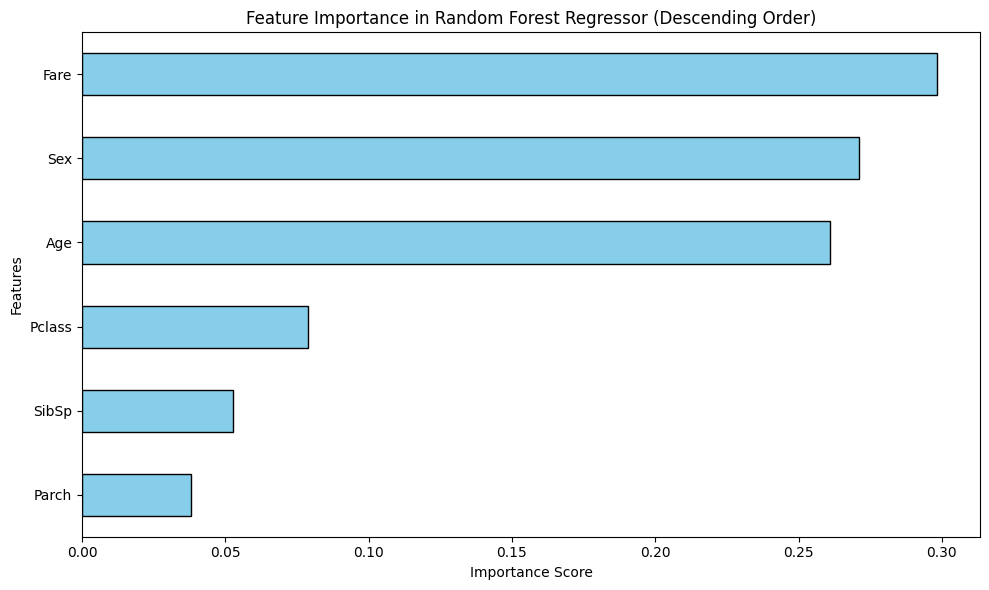

In [8]:
## 8. Feature Importance
# ------------------------------------------
# Create a pandas Series mapping importance scores to feature names
feat_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)

# Sort the features in ascending order for the horizontal bar plot
# (Matplotlib plots from the bottom up, so ascending order puts the highest value at the top)
feat_importances_sorted = feat_importances.sort_values(ascending=True)

# Plot the sorted feature importances
plt.figure(figsize=(10, 6))
feat_importances_sorted.plot(kind='barh', color='skyblue', edgecolor='black')

# Customize chart labels and title
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regressor (Descending Order)')

# Adjust layout to prevent clipping of labels and display the plot
plt.tight_layout()
plt.show()

### Regression Task

Advantages

Random Forest Regression offers several benefits when working with complex datasets.

 - Handles non linearity: Captures complex relationships between features and the target variable.
 - Reduces overfitting: Combines multiple decision trees to produce more stable predictions.
 - Robust to outliers: Averaging predictions from many trees reduces the effect of extreme values.
 - Works with large datasets: Performs well even with high dimensional data.
 - Handles missing data: Can maintain good accuracy even when some values are missing.
 - No feature scaling required: Does not require normalization or scaling of input data.

Limitations

Random Forest Regression also has some limitations that should be considered when using the model.

 - Computational complexity: Training many decision trees can be slow and computationally expensive.
 - Less interpretability: Harder to interpret compared to simpler models like linear regression or a single decision tree.
 - Memory intensive: Storing multiple trees requires significant memory for large datasets.
 - Overfitting on noisy data: The model may still overfit when the dataset contains a lot of noise.
 - Sensitive to imbalanced data: Performance may decrease when one class is much more frequent than others.

In [9]:
## 1. Import Libraries
# ------------------------------------------
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output presentation
warnings.filterwarnings('ignore')

In [10]:
## 2. Load and Prepare the Dataset
# ------------------------------------------
# Fetch the raw California Housing dataset from sklearn
california_housing = fetch_california_housing()

# Convert the feature data into a structured pandas DataFrame
california_data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)

# Add the target variable (Median House Value in $100,000s) to the DataFrame
california_data['MEDV'] = california_housing.target

In [11]:
california_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MEDV
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
## 3. Feature and Target Selection
# ------------------------------------------
# Separate the independent features (X) by dropping the target column
X = california_data.drop('MEDV', axis=1)

# Define the dependent target variable (y)
y = california_data['MEDV']

In [13]:
## 4. Split Data into Train and Test Sets
# ------------------------------------------
# Partition the data: 80% for training the model and 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
## 5. Model Training
# ------------------------------------------
# Initialize the Random Forest Regressor with 100 decision trees
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the regressor using the training dataset
rf_regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
## 6. Model Evaluation
# ------------------------------------------
# Make predictions on the unseen test data
y_pred = rf_regressor.predict(X_test)

# Calculate evaluation metrics: Mean Squared Error (MSE) and R-squared (R²) score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 0.26
R-squared Score: 0.80


In [16]:
## 7. Model Inference (Single Prediction)
# ------------------------------------------
# Extract the very first row from the test set and reshape it for a single prediction
single_data = X_test.iloc[0].values.reshape(1, -1)

# Use the trained model to predict the house value for this specific sample
predicted_value = rf_regressor.predict(single_data)

# Print and compare the predicted value against the actual true value
print(f"Predicted Value: {predicted_value[0]:.2f}")
print(f"Actual Value: {y_test.iloc[0]:.2f}")

Predicted Value: 0.51
Actual Value: 0.48


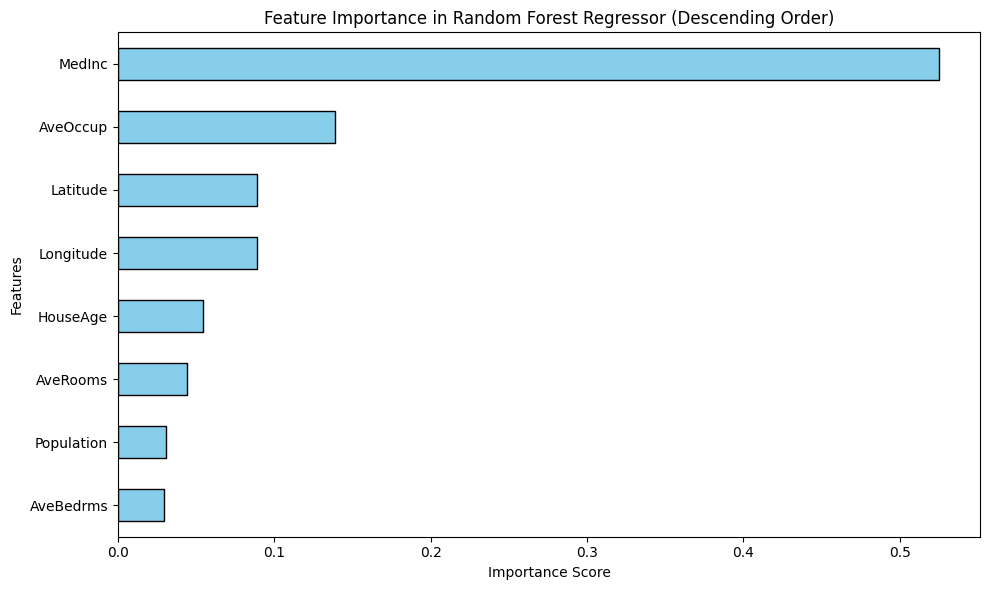

In [17]:
## 8. Feature Importance
# ------------------------------------------
# Create a pandas Series mapping importance scores to feature names
feat_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns)

# Sort the features in ascending order for the horizontal bar plot
# (Matplotlib plots from the bottom up, so ascending order puts the highest value at the top)
feat_importances_sorted = feat_importances.sort_values(ascending=True)

# Plot the sorted feature importances
plt.figure(figsize=(10, 6))
feat_importances_sorted.plot(kind='barh', color='skyblue', edgecolor='black')

# Customize chart labels and title
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regressor (Descending Order)')

# Adjust layout to prevent clipping of labels and display the plot
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [18]:
## 1. Import Libraries
# ------------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [19]:
## 2. Load and Inspect the Dataset
# ------------------------------------------
# Load the heart disease dataset from the local data directory
data = pd.read_csv("../data/heart.csv")

# Display the first 7 rows to inspect features and values
print("--- First 7 Rows of Dataset ---")
print(data.head(7))

--- First 7 Rows of Dataset ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   
5   58    0   0       100   248    0        0      122      0      1.0      1   
6   58    1   0       114   318    0        2      140      0      4.4      0   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
5   0     2       1  
6   3     1       0  


In [20]:
## 3. Feature and Target Selection
# ------------------------------------------
# Separate features (X) by dropping the 'target' column
X = data.drop("target", axis=1)

# Define the target variable (y) where 1 indicates disease and 0 indicates health
y = data['target']

In [21]:
## 4. Split Data into Train and Test Sets
# ------------------------------------------
# Partition the data: 75% for training and 25% for testing
# random_state ensures reproducibility across different runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
## 5. Model Initialization and Hyperparameter Tuning
# ------------------------------------------
# Initialize the Random Forest Classifier with specific hyperparameters:
# - n_estimators: 100 decision trees in the forest
# - max_features: The number of features to consider when looking for the best split (square root of total features)
# - max_depth: Maximum depth of individual trees limited to 6 to prevent overfitting
# - max_leaf_nodes: Grow trees with a maximum of 6 leaf nodes for a simpler model
model = RandomForestClassifier(
    n_estimators=100, 
    max_features="sqrt", 
    max_depth=6, 
    max_leaf_nodes=6,
    random_state=42  # Added for deterministic behavior
)

In [23]:

## 6. Model Training
# ------------------------------------------
# Fit the Random Forest model on the training data
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [24]:
## 7. Model Evaluation
# ------------------------------------------
# Make predictions on the unseen test dataset
y_pred = model.predict(X_test)

In [25]:
# Generate and print a comprehensive evaluation report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred)) # Fixed order to (y_true, y_pred) for correct metrics


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.81       132
           1       0.77      0.91      0.83       125

    accuracy                           0.82       257
   macro avg       0.83      0.82      0.82       257
weighted avg       0.83      0.82      0.82       257



In [26]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Estimator: RandomForestClassifier(max_depth=10, max_features=0.5, n_estimators=200)


In [27]:
model_grid = RandomForestClassifier(**grid_search.best_params_)
model_grid.fit(X_train, y_train)
y_pred_grid = model_grid.predict(X_test)
print(classification_report(y_pred_grid, y_test))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       138
           1       0.95      1.00      0.98       119

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257



In [28]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

random_search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_grid, cv=5, n_jobs=-1, verbose=1)
random_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Estimator: RandomForestClassifier(max_depth=10, max_features=0.5, n_estimators=200)


In [29]:
model_grid = RandomForestClassifier(**random_search.best_params_)
model_grid.fit(X_train, y_train)
y_pred_grid = model_grid.predict(X_test)
print(classification_report(y_pred_grid, y_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       135
           1       0.98      1.00      0.99       122

    accuracy                           0.99       257
   macro avg       0.99      0.99      0.99       257
weighted avg       0.99      0.99      0.99       257

